<a href="https://colab.research.google.com/github/srijabiswas-01/audio_analysis/blob/main/audio_spliter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!apt-get -qq update
!apt-get -qq install -y ffmpeg
!pip -q install demucs soundfile librosa ffmpeg-python

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.1/87.1 kB 8.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.3/249.3 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 9.0 MB/s eta 0:00:00


In [ ]:
!pip install demucs

In [ ]:
from google.colab import files
import subprocess
from pathlib import Path
import librosa
import shutil

In [ ]:
# Maximum allowed duration (8 minutes = 480 seconds)
MAX_DURATION_SECONDS = 8 * 60

# Upload file
uploaded = files.upload()

input_filename = next(iter(uploaded.keys()))
print("Uploaded:", input_filename)

# Check duration before processing
try:
    duration = librosa.get_duration(path=input_filename)
except TypeError:
    # Fallback for older librosa versions
    y, sr = librosa.load(input_filename, sr=None, mono=True)
    duration = librosa.get_duration(y=y, sr=sr)

minutes = int(duration // 60)
seconds = int(duration % 60)

print(f"Audio Duration: {minutes} min {seconds} sec")

if duration > MAX_DURATION_SECONDS:
    raise ValueError(
        f"❌ Audio is too long ({minutes}m {seconds}s). "
        f"Please upload a file that is 8 minutes or shorter."
    )

print("✅ Duration check passed.")

Saving Ae Ajnabi.mp3 to Ae Ajnabi.mp3
Uploaded: Ae Ajnabi.mp3
Audio Duration: 5 min 40 sec
✅ Duration check passed.


In [ ]:
# uploaded = files.upload()
# input_filename = next(iter(uploaded.keys()))
# print("Uploaded:", input_filename)

In [ ]:
input_path = Path(input_filename)
converted_path = "input_audio.wav"

subprocess.run([
    "ffmpeg",
    "-y",
    "-i",
    str(input_path),
    "-ar", "44100",
    "-ac", "2",
    converted_path
], check=True)

print("Converted to:", converted_path)

Converted to: input_audio.wav


In [ ]:
subprocess.run([
    "python",
    "-m",
    "demucs",
    "--mp3",
    "--filename",
    "{track}/{stem}.{ext}",
    converted_path
], check=True)

print("Separation complete.")

Separation complete.


In [ ]:
root = Path("separated/htdemucs/input_audio")
print("Generated files:")
for f in root.glob("*"):
    print("-", f)

Generated files:
- separated/htdemucs/input_audio/bass.mp3
- separated/htdemucs/input_audio/drums.mp3
- separated/htdemucs/input_audio/other.mp3
- separated/htdemucs/input_audio/vocals.mp3


In [ ]:
zip_path = shutil.make_archive(
    "demucs_output",
    "zip",
    root_dir=root
)
print(zip_path)

/content/demucs_output.zip


In [ ]:
files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip -q install plotly mutagen pandas

In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from mutagen import File
from IPython.display import Audio, display
from pathlib import Path
import os

In [ ]:
root = Path("separated/htdemucs/input_audio")

stem_files = {
    "Vocals": root / "vocals.mp3",
    "Drums": root / "drums.mp3",
    "Bass": root / "bass.mp3",
    "Other": root / "other.mp3",
}

In [ ]:
metadata_rows = []

for stem_name, file_path in stem_files.items():

    y, sr = librosa.load(file_path, sr=None)

    duration = librosa.get_duration(y=y, sr=sr)

    metadata_rows.append({
        "Stem": stem_name,
        "File": os.path.basename(file_path),
        "Duration (sec)": round(duration, 2),
        "Sample Rate": sr,
        "Channels": 1 if y.ndim == 1 else y.shape[0],
        "RMS Energy": round(float(np.sqrt(np.mean(y**2))), 5),
        "Peak Amplitude": round(float(np.max(np.abs(y))), 5),
        "File Size (MB)": round(os.path.getsize(file_path)/(1024*1024), 2)
    })

metadata_df = pd.DataFrame(metadata_rows)
metadata_df

In [ ]:
for stem_name, file_path in stem_files.items():
    print("=" * 60)
    print(stem_name)
    display(Audio(str(file_path)))

In [16]:
for stem_name, file_path in stem_files.items():

    y, sr = librosa.load(file_path, sr=None)

    t = np.linspace(0, len(y)/sr, len(y))

    fig = go.Figure()

    fig.add_trace(
        go.Scatter(
            x=t,
            y=y,
            mode="lines",
            name=stem_name
        )
    )

    fig.update_layout(
        title=f"{stem_name} Waveform",
        xaxis_title="Time (seconds)",
        yaxis_title="Amplitude"
    )

    fig.show()

Buffered data was truncated after reaching the output size limit.

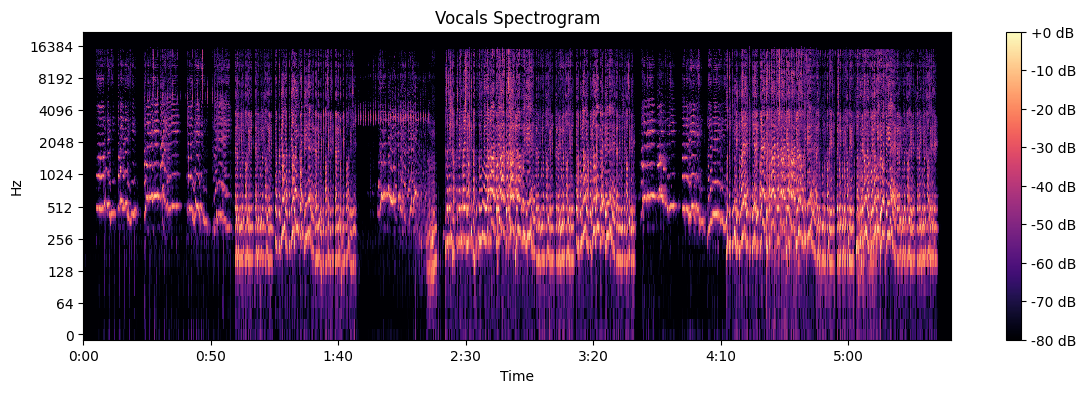

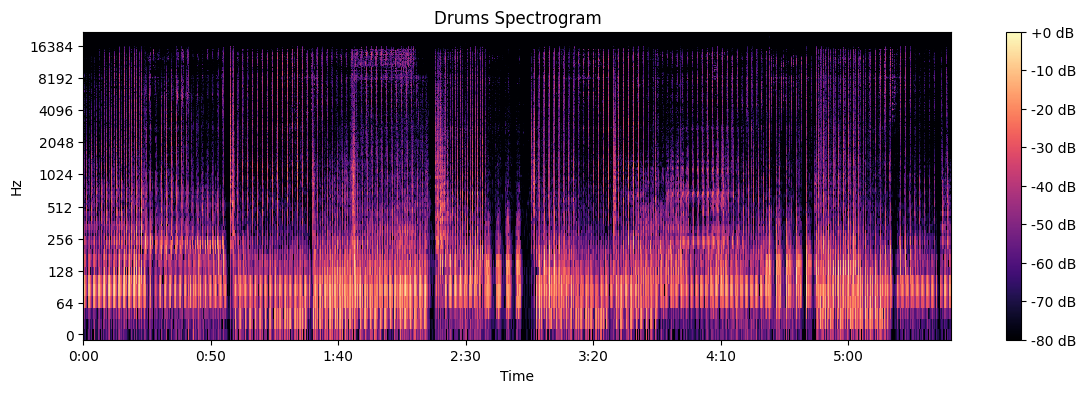

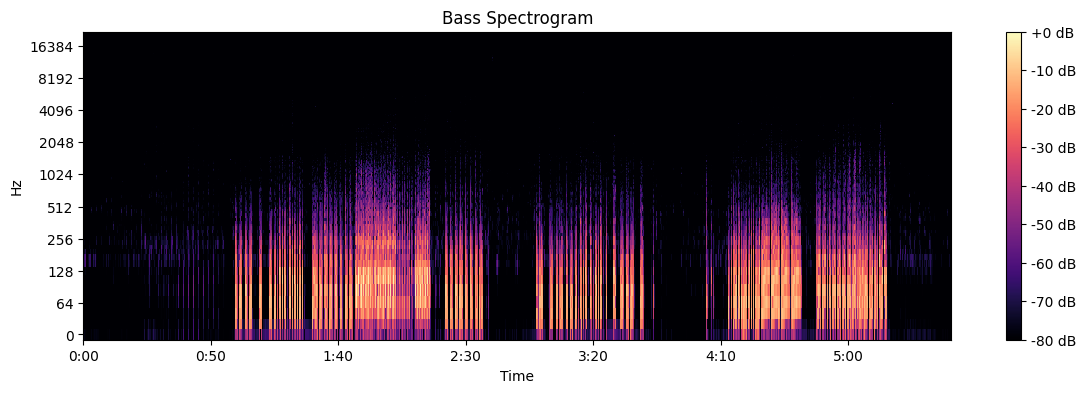

In [ ]:
for stem_name, file_path in stem_files.items():

    y, sr = librosa.load(file_path, sr=None)

    plt.figure(figsize=(14,4))

    D = librosa.amplitude_to_db(
        np.abs(librosa.stft(y)),
        ref=np.max
    )

    librosa.display.specshow(
        D,
        sr=sr,
        x_axis="time",
        y_axis="log"
    )

    plt.colorbar(format="%+2.0f dB")
    plt.title(f"{stem_name} Spectrogram")
    plt.show()

In [ ]:
for stem_name, file_path in stem_files.items():

    y, sr = librosa.load(file_path, sr=None)

    f0, voiced_flag, voiced_probs = librosa.pyin(
        y,
        fmin=librosa.note_to_hz("C2"),
        fmax=librosa.note_to_hz("C7")
    )

    times = librosa.times_like(f0, sr=sr)

    plt.figure(figsize=(14,4))

    plt.plot(times, f0)

    plt.title(f"{stem_name} Pitch (F0)")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Frequency (Hz)")

    plt.show()

In [ ]:
for stem_name, file_path in stem_files.items():

    y, sr = librosa.load(file_path, sr=None)

    fft = np.abs(np.fft.rfft(y))
    freqs = np.fft.rfftfreq(len(y), 1/sr)

    fig = go.Figure()

    fig.add_trace(
        go.Scatter(
            x=freqs,
            y=fft,
            mode="lines"
        )
    )

    fig.update_layout(
        title=f"{stem_name} Frequency Spectrum",
        xaxis_title="Frequency (Hz)",
        yaxis_title="Magnitude"
    )

    fig.show()

In [ ]:
import librosa
import soundfile as sf
from IPython.display import Audio, display

# Load separated vocals
y, sr = librosa.load("separated/htdemucs/input_audio/vocals.mp3", sr=None)

# Shift pitch by +3 semitones
shift_semitones = 3

y_shifted = librosa.effects.pitch_shift(
    y,
    sr=sr,
    n_steps=shift_semitones
)

# Save result
output_file = "vocals_pitch_plus3.wav"
sf.write(output_file, y_shifted, sr)

print("Saved:", output_file)

# Listen in Colab
display(Audio(output_file))